In [69]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt


# ─── ✤ LOADING DATASET AS PANDAS DATAFRAME ✤ ───

In [70]:
df_car = pd.read_csv("C:\\Users\\Lenovo\\Documents\\GitHub\\Fullstack_AI\\Data_sets\\Classifications\\Section-A-Q2-Car_processing_after_tfidf_context.csv")
df_car = df_car.sample(50000, random_state=42)

   Since the dataframe is too huge and this system doesn't supports extremly complex calculations.   
   so we are taking random 50000 samples , out of the dataset for model training.

# ___________________________________________________________________________________________________________________________

# ─── ✤ DATA STUDY AND ANALYZING ✤ ───

In [71]:
print("Shape of data set : " , df_car.shape , "\n")
print("Info of dataset : " , df_car.info() , "\n")
print("colomns of dataset : " , df_car.columns , "\n")
print("Finding null values : " , df_car.isnull().sum() , "\n")
print("Finding Duplicates of dataset : " , df_car.duplicated().sum() , "\n" ) 
print("Mathematical calculations of each column of dataset : " , df_car.describe() , "\n" )                                
print("Value count of target column : " , df_car["BodyType"].value_counts())
 

Shape of data set :  (50000, 32) 

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 207089 to 141562
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Brand                     50000 non-null  object 
 1   Model                     50000 non-null  object 
 2   BodyType                  50000 non-null  object 
 3   Category                  50000 non-null  object 
 4   Drive                     49725 non-null  object 
 5   Doors                     50000 non-null  int64  
 6   Km                        50000 non-null  int64  
 7   YearBuilt                 50000 non-null  int64  
 8   Power_kW_HP               50000 non-null  int64  
 9   EngineCapacity            50000 non-null  float64
 10  Cylinders                 49924 non-null  float64
 11  EmptyWeight               49904 non-null  float64
 12  EmissionClass             49932 non-null  object 
 13  FuelType                 

This dataset has 32 columns and 334,851 rows. It contains different data types including object, float, int, and bool, which means it has both numerical and categorical features.

There are 10 columns with missing values, and 10,151 duplicate rows are present.

Now, we move on to identifying the target column.


# ─── ✤ EXPLORATORY DATA ANALYSIS WITH VISUALIZING ✤ ───

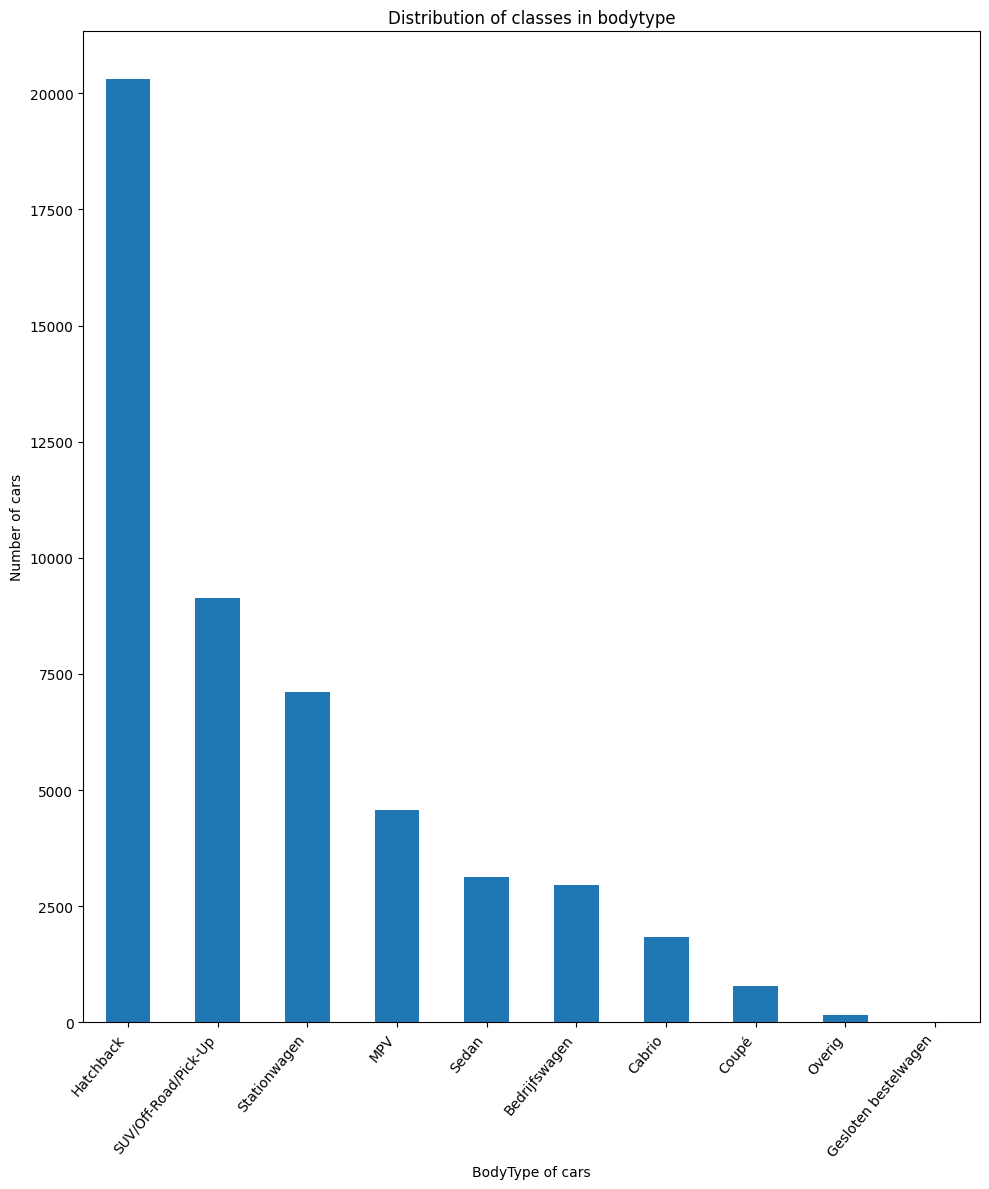

In [72]:
bodytype_counts = df_car['BodyType'].value_counts()

plt.figure(figsize=(10,12))
bodytype_counts.plot(kind = 'bar')
plt.title("Distribution of classes in bodytype")
plt.xlabel("BodyType of cars")
plt.ylabel("Number of cars")
plt.xticks(rotation= 50, ha='right')
plt.tight_layout()
plt.show()

This chart indicates class imbalance, where hatchbacks and SUVs dominate, while other categories such as coupes and Gesloten bestelwagen appear far less frequently.  
 This imbalance can negatively affect model training by introducing bias toward the majority classes.

<Figure size 1200x700 with 0 Axes>

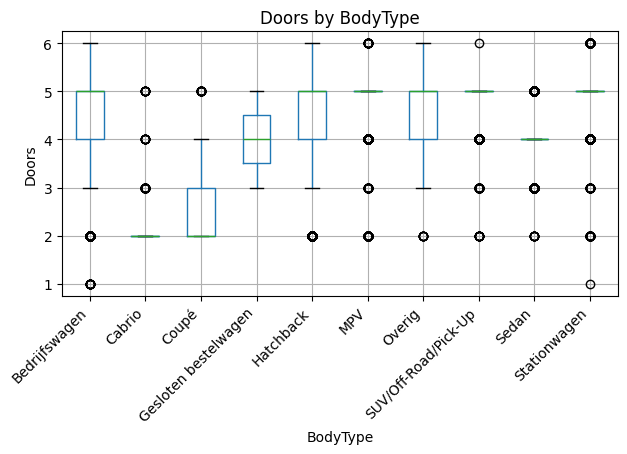

<Figure size 1200x700 with 0 Axes>

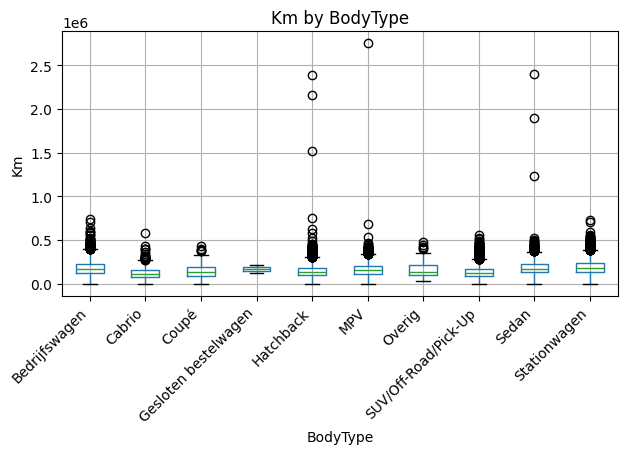

<Figure size 1200x700 with 0 Axes>

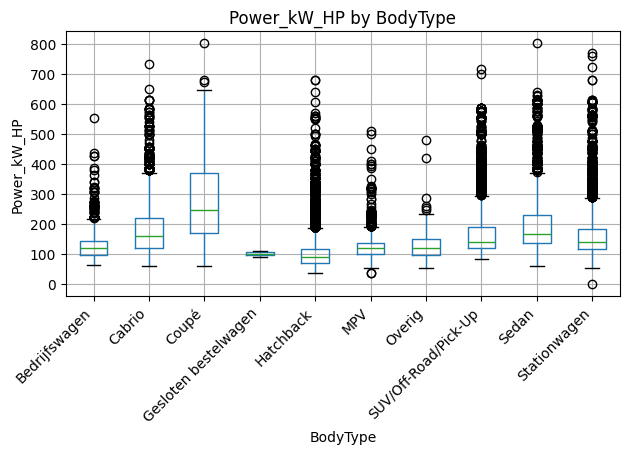

<Figure size 1200x700 with 0 Axes>

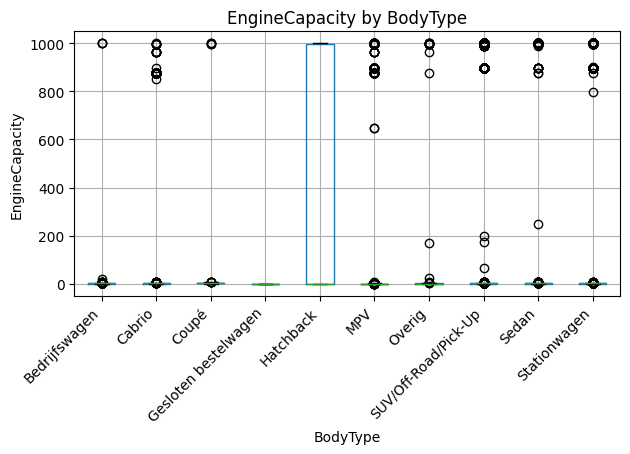

<Figure size 1200x700 with 0 Axes>

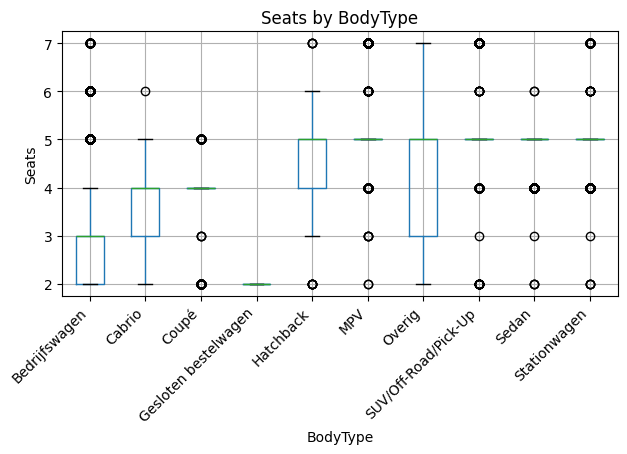

<Figure size 1200x700 with 0 Axes>

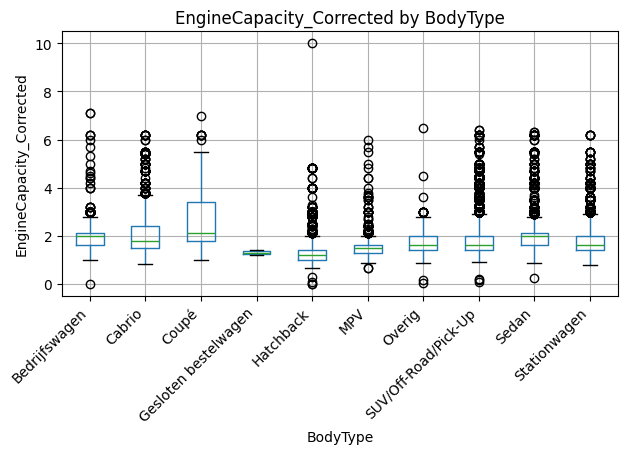

In [73]:
num_col_to_check = ['Doors' , 'Km' , 'Power_kW_HP' , 'EngineCapacity' , 'Seats' , 'EngineCapacity_Corrected' ]

for cols in num_col_to_check:
    plt.figure(figsize=(12, 7))
    df_car.boxplot(column=cols, by='BodyType')
    plt.title(f'{cols} by BodyType')
    plt.suptitle("")
    plt.xlabel('BodyType')
    plt.ylabel(cols)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

The box plots show how key features vary across different body types. For example, engine capacity differs significantly by body type.

These plots also reveal outliers in some features, such as extremely high mileage values (up to one million kilometers), which can bias model training by overly influencing certain body types.

This analysis examines the relationship between bodyType and important features like mileage, engine capacity, doors, seats, power, shape, wheelbase, and cargo volume, helping both the model and the analyst identify patterns more clearly.

# ___________________________________________________________________________________________________________________________

# ─── ✤ DATA CLEANING ✤ ───

In [74]:
print("Shape before removing duplicate rows : " , df_car.shape)
df_car = df_car.drop_duplicates()
print("Shape After removing duplicate rows : " , df_car.shape)

Shape before removing duplicate rows :  (50000, 32)
Shape After removing duplicate rows :  (49695, 32)


In [75]:
print("Before removing the unnecessry columns , total columns were " , df_car.shape )
df_car = df_car.drop(columns=['APK' , 'Category' , "APK_month_diff" ,'Color'])
print("After removing the unnecessry columns , total columns were " , df_car.shape )

Before removing the unnecessry columns , total columns were  (49695, 32)
After removing the unnecessry columns , total columns were  (49695, 28)


These columns do not help in predicting the body type of the car. The APK column is almost entirely empty, while the categories column contains only a single repeated value. Since there is no meaningful variation, these features do not contribute useful information for prediction.

In [76]:
num_col = []
cat_col = []

for column in df_car.columns:
    if df_car[column].dtype != 'object':
      num_col.append(column)
    #All the columns , other than of object data datatype , will go to numeric column's list 
for column in df_car.columns:
    if df_car[column].dtype == 'object':
      cat_col.append(column)
    #All the columns , having object data datatype , will go to catagorical column's list 
print("Numeric column : " , num_col )
print("String column  : " , cat_col )

Numeric column :  ['Doors', 'Km', 'YearBuilt', 'Power_kW_HP', 'EngineCapacity', 'Cylinders', 'EmptyWeight', 'Price', 'Seats', 'FullServiceHistory', 'Gears', 'CO2Emission', 'FuelConsumption', 'PreviousOwners', 'NonSmokingCar', 'EngineCapacity_Corrected', 'A1', 'A2', 'A3', 'A4']
String column  :  ['Brand', 'Model', 'BodyType', 'Drive', 'EmissionClass', 'FuelType', 'Transmission', 'Warranty']


Since numerical and categorical columns cannot be handled in the same way, we separated them into different groups.   
This separation allows us to deal with missing values more effectively by applying appropriate methods to each type of column.

In [77]:
for column in num_col:
   df_car[column] = df_car[column].fillna(df_car[column].median())
for column in cat_col:
   df_car[column] = df_car[column].fillna('unknown')

All categorical column missing values are filled with "Unknown", while numerical columns are filled using the median of their respective columns.

In [78]:
print("After removing all the missing values we check : " , df_car.isnull().sum())

After removing all the missing values we check :  Brand                       0
Model                       0
BodyType                    0
Drive                       0
Doors                       0
Km                          0
YearBuilt                   0
Power_kW_HP                 0
EngineCapacity              0
Cylinders                   0
EmptyWeight                 0
EmissionClass               0
FuelType                    0
Price                       0
Seats                       0
FullServiceHistory          0
Transmission                0
Gears                       0
CO2Emission                 0
Warranty                    0
FuelConsumption             0
PreviousOwners              0
NonSmokingCar               0
EngineCapacity_Corrected    0
A1                          0
A2                          0
A3                          0
A4                          0
dtype: int64


# ___________________________________________________________________________________________________________________________

# ─── ✤ PREPROCESSING ✤ ───

In [79]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

This step transforms the dataset into a format the model can understand. Since models cannot interpret categorical (alphabetic) data, we encode these columns into numbers using One-Hot Encoding (binary 0–1 combinations).   

Additionally, features with large value ranges, such as mileage (km), can bias or confuse the model. To address this, we scale numerical features to a 0–1 range using StandardScaler.

error occured : An error occurred during model training because the target column BodyType was included in the preprocessing step. Since the target column is removed from the feature set before training, it was not found in x_train, which caused the error. The problem was fixed by excluding the target column from the preprocessing . 

In [80]:
cat_col.remove("BodyType")

In [81]:
df_car_preprocess = ColumnTransformer(
    transformers=[
        ('n', StandardScaler(), num_col),
        ('c', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_col)])
    

Because multiple transformations are required, scikit-learn’s ColumnTransformer provides an efficient solution. It applies both transformations in a single step:   
– n scales numerical features using StandardScaler   
– c encodes categorical features using One-Hot Encoding

# ─── ✤ FEATURE ENGINEERING ✤ ───

Some feature engineering techniques involve creating new columns from existing ones to extract more meaningful information.

For example, A car built in 2006 and one built in 2018 may have the same body type (e.g., SUV) but very different in Size ,Technology,Safety standards. The model cannot automatically know which year is earlier, so we create an age column:

In [82]:
df_car['Vehicle_Year'] = 2018 - df_car['YearBuilt']

# ___________________________________________________________________________________________________________________________

# ─── ✤ MODELING ✤ ───

In [83]:
from sklearn.model_selection import train_test_split

Now ,  dataset is divided into two:   
_input features (X) by removing the target column.  
_The target variable (Y) is set as the BodyType column for prediction.

In [84]:
X = df_car.drop(columns = 'BodyType')
Y = df_car['BodyType']

The data is then split into training and testing sets using train_test_split method:  
  -80% of the data is used for training.  
  -20% of the data is reserved for testing.

In [85]:
x_train , x_test , y_train , y_test = train_test_split(X , Y, test_size=0.2 , random_state=42 )

In this line, the function splits the data into training sets x_train (input features) and y_train (target column) on which the model will be trained,  
and testing sets x_test (input features) and y_test (target column) on which the data will be tested after prediction. 

In [86]:
print(f"shape of x_train : {x_train.shape} \n")
print(f"shape of y_train : {y_train.shape} \n")
print(f"shape of x_test : {x_test.shape} \n")
print(f"shape of x_test : {x_test.shape} \n")

shape of x_train : (39756, 28) 

shape of y_train : (39756,) 

shape of x_test : (9939, 28) 

shape of x_test : (9939, 28) 



In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC

Now we train the models using pipelines so everything happens in the right order. The pipeline makes sure the data is prepared first and then the model is trained, without mixing training and testing data. 

# Models :-

We train four models, and each model is placed inside a pipeline along with the data preparation steps.

1. Logistic Regression :

In [88]:
LR_pipeline = Pipeline(
    steps=[
        ('preprocessing', df_car_preprocess),
        ('model', LogisticRegression(class_weight='balanced' , max_iter=1000))])

LR_pipeline.fit(x_train , y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('n', ...), ('c', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

Here we make a pipeline for Logistic Regression.  
_First, the data is cleaned and prepared using the preprocessing step  
_Then the Logistic Regression model is trained.   
_The pipeline makes sure these steps run in the right order.   
_Finally, we train the pipeline using the training data (x_train and y_train).

Logistic Regression learns the relationship between input features and the target class.It is used because it is simple, fast, and easy to understand for classification tasks.

2. Random Forest :

In [89]:
RF_pipeline = Pipeline(
    steps=[
        ('preprocessing', df_car_preprocess),
        ('model', RandomForestClassifier())])
RF_pipeline.fit(x_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('n', ...), ('c', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

Here we make a pipeline for the Random Forest model. We use the Random Forest model because it is strong, works well with many features, understands complex patterns in the data, and does not overfit easily. it gives better accuracy by combining many decision trees.

3. Decision Tree:

In [90]:
DT_pipeline = Pipeline(
    steps=[
        ('preprocessing', df_car_preprocess),
        ('model', DecisionTreeClassifier())])
DT_pipeline.fit(x_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('n', ...), ('c', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

A Decision Tree splits the data step by step to make predictions.
It is easy to visualize and explain, which makes it good for understanding the data.

4. Linear SVC:

In [91]:
L_SVC_pipeline = Pipeline(
    steps=[
        ('preprocessing', df_car_preprocess),
        ('model', LinearSVC(class_weight='balanced'))])
L_SVC_pipeline.fit(x_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('n', ...), ('c', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

Linear SVC is used because it separates classes using a straight line and works well with high-dimensional data.

# ___________________________________________________________________________________________________________________________

# ─── ✤ EVALUATION ✤ ───

In [92]:
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

Here we test all the models trained above. For every model: 
- We predict results on test data.
- We check the classification report.
- We display the confusion matrix.

LOGISTIC REGRESSTION

In [93]:
LR_y_pred = LR_pipeline.predict(x_test)
print("\nPrediction through logistic regression: \n " , LR_y_pred)
print(classification_report(y_test, LR_y_pred))


Prediction through logistic regression: 
  ['Stationwagen' 'SUV/Off-Road/Pick-Up' 'Hatchback' ... 'Bedrijfswagen'
 'Hatchback' 'Hatchback']


c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                      precision    recall  f1-score   support

       Bedrijfswagen       0.97      0.90      0.94       582
              Cabrio       0.82      0.88      0.85       404
               Coupé       0.56      0.87      0.68       164
Gesloten bestelwagen       0.00      0.00      0.00         0
           Hatchback       0.95      0.79      0.87      4105
                 MPV       0.83      0.89      0.86       853
              Overig       0.04      0.33      0.07        33
SUV/Off-Road/Pick-Up       0.95      0.96      0.96      1785
               Sedan       0.69      0.80      0.74       639
        Stationwagen       0.70      0.79      0.74      1374

            accuracy                           0.84      9939
           macro avg       0.65      0.72      0.67      9939
        weighted avg       0.88      0.84      0.85      9939



c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



The insights from this classification report are that this model predicts large classes very well, but struggles with smaller classes.
here is the results with there f1 score 

- Very good predictions on:

    - SUV / Off-Road / Pick-Up → 96%
    - Bedrijfswagen → 94%
    - Hatchback → 87%
    - MPV → 86%

 The model is strong where there is plenty of data.

- Average performance on:

    - Sedan → 74%
    - Stationwagen → 74%

Since both have similar shape , size aand features. The model gets confused by similar but slightly different body types:

- Weak prediction on:

    - Coupé → 68%
    - Overig → 07%
    - Gesloten bestelwagen → 0%

These classes bearly had any data .The model is not reliable for rare classes.

In [94]:
print("Accuracy    :", accuracy_score(y_test, LR_y_pred))
print("Macro F1    :", f1_score(y_test, LR_y_pred, average='macro'))
print("Weighted F1 :", f1_score(y_test, LR_y_pred, average='weighted'))

Accuracy    : 0.8416339671999196
Macro F1    : 0.6701995844949177
Weighted F1 : 0.8548296727564791


Accuracy = 84% 
    Which means it is giving mostly right predictions. specialy on larger data . 

Macro F1 = 67%
    which means the model performs only moderately when all classes are given equal importance.

Weighted F1 = 85%
    which means that the model works well for the most common classes, which have more samples.

In [ ]:
cm = confusion_matrix(y_test, LR_y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

since the mostly models encode the target columns by themselve thats why the body types are indicated as numbers not the names .

The diagonal values show correct predictions, and most values are on the diagonal, meaning the model predicts many samples correctly.

Large diagonal numbers indicate strong performance for common classes like Hatchback, SUV, and Stationwagen.

Off-diagonal values show where the model gets confused, mostly between similar body types.

RANDOM FOREST

In [96]:
RF_y_pred = RF_pipeline.predict(x_test)
print("\nPrediction through Random Forest: \n " , RF_y_pred)
print(classification_report(y_test, RF_y_pred))


Prediction through Random Forest: 
  ['Stationwagen' 'SUV/Off-Road/Pick-Up' 'Hatchback' ... 'Bedrijfswagen'
 'Hatchback' 'Hatchback']
                      precision    recall  f1-score   support

       Bedrijfswagen       0.97      0.98      0.98       582
              Cabrio       0.88      0.91      0.89       404
               Coupé       0.83      0.55      0.66       164
           Hatchback       0.91      0.96      0.94      4105
                 MPV       0.91      0.82      0.86       853
              Overig       1.00      0.15      0.26        33
SUV/Off-Road/Pick-Up       0.92      0.98      0.95      1785
               Sedan       0.90      0.74      0.81       639
        Stationwagen       0.85      0.79      0.82      1374

            accuracy                           0.91      9939
           macro avg       0.91      0.77      0.80      9939
        weighted avg       0.90      0.91      0.90      9939



- Very good predictions on:

    - Bedrijfswagen → 97%
    - SUV / Off-Road / Pick-Up → 95%
    - Hatchback → 94%
    - MPV → 87%
    - Cabrio → 89%

- Average performance on:

    - Sedan → 82%
    - Stationwagen → 81%

- Weak predictions on:

    - Coupe → 69%
    - Overig → 26%

In [ ]:
print("Accuracy    :", accuracy_score(y_test, RF_y_pred))
print("Macro F1    :", f1_score(y_test, RF_y_pred, average='macro'))
print("Weighted F1 :", f1_score(y_test, RF_y_pred, average='weighted'))

Accuracy = 91%
 The model gives mostly correct predictions, especially for large and well-represented classes.

Macro F1 = 80%
 The model performs reasonably when all classes are given equal importance, but weaker classes reduce the overall score.

Weighted F1 = 90%
 The model performs very well on the most common classes, which have more samples and higher influence.

In [ ]:
cm = confusion_matrix(y_test, RF_y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

DECISION TREE

In [ ]:
DT_y_pred = DT_pipeline.predict(x_test)
print("\nPrediction through Desision Tree: \n " , DT_y_pred)
print(classification_report(y_test, DT_y_pred))

-  Strongly Predicted 

   - Bedrijfswagen → 95%
   - SUV / Off-Road / Pick-Up → 93%
   - Hatchback → 92%
   - Cabrio → 89%

- Average Performance 

   - Sedan → 76%
   - Stationwagen → 78%
   - Coupé → 74%
   - MPV → 81%

- Weakly Predicted Class

    - Overig → 24%


In [ ]:
print("Accuracy    :", accuracy_score(y_test, DT_y_pred))
print("Macro F1    :", f1_score(y_test, DT_y_pred, average='macro'))
print("Weighted F1 :", f1_score(y_test, DT_y_pred, average='weighted'))

Accuracy = 88%
 The model predicts most cars correctly.

Weighted F1 = 88%
 The model performs very well on common classes with more data.

Macro F1 = 78%
 When all classes are treated equally, performance drops, showing weaker results on small classes.

In [ ]:
cm = confusion_matrix(y_test, DT_y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

LINEAR SVC

In [ ]:
L_SVC_y_pred = L_SVC_pipeline.predict(x_test)
print("\nPrediction through linear svc: \n " , L_SVC_y_pred)
print(classification_report(y_test, L_SVC_y_pred))

-  Strongly Predicted 

    - Bedrijfswagen → 98%
    - SUV / Off-Road / Pick-Up → 96%
    - Hatchback → 90%
    - MPV → 86%

- Average Performance 

    - Cabrio → 83%
    - Stationwagen → 71%
    - Sedan → 68%

- Weakly Predicted Class

    - Coupé → 66%
    - Overig → 12%

In [ ]:
print("Accuracy    :", accuracy_score(y_test, DT_y_pred))
print("Macro F1    :", f1_score(y_test, L_SVC_y_pred, average='macro'))
print("Weighted F1 :", f1_score(y_test, L_SVC_y_pred, average='weighted'))

Accuracy = 86%
→ The model predicts most vehicles correctly.

Weighted F1 = 86%
→ The model works well on common classes with more data.

Macro F1 = 74%
→ When all classes are treated equally, performance is lower, indicating weaker predictions for minority classes.

In [ ]:
cm = confusion_matrix(y_test, L_SVC_y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Overall, all models perform reasonably well, with accuracy ranging from 84% to 91%, and the highest accuracy achieved by the Random forest.

# ─── ✤ COMPARISION CHARTS ✤ ───

In [111]:
model_names = [
    'Logistic Regression',
    'Random Forest',
    'Decision Tree',
    'Linear SVC'
]

These are the model name we will compare r.w.t there accuracy score , macro f1 , weight f1

In [107]:
accuracy_scores = [
    accuracy_score(y_test, LR_y_pred),
    accuracy_score(y_test, RF_y_pred),
    accuracy_score(y_test, DT_y_pred),
    accuracy_score(y_test, L_SVC_y_pred)
]

List of all models accuray score

In [108]:
macro_f1_scores = [
    f1_score(y_test, LR_y_pred, average='macro'),
    f1_score(y_test, RF_y_pred, average='macro'),
    f1_score(y_test, DT_y_pred, average='macro'),
    f1_score(y_test, L_SVC_y_pred, average='macro')
]

List of all models macro f1.

In [109]:
weighted_f1_scores = [
    f1_score(y_test, LR_y_pred, average='weighted'),
    f1_score(y_test, RF_y_pred, average='weighted'),
    f1_score(y_test, DT_y_pred, average='weighted'),
    f1_score(y_test, L_SVC_y_pred, average='weighted')
]

List of all models weight f1 score.

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(model_names, accuracy_scores)
plt.title("Model Comparison — Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.ylim(0,1)
plt.show()

Random Forest has the highest accuracy, making it the best overall performer in terms of correct predictions.

Decision Tree is the second best, showing strong accuracy but slightly lower than Random Forest.

Linear SVC performs well but is slightly less accurate than Decision Tree.

Logistic Regression has the lowest accuracy among the four models, though it still performs reasonably well.

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(model_names, macro_f1_scores)
plt.title("Model Comparison — Macro F1 Score")
plt.xlabel("Models")
plt.ylabel("Macro F1")
plt.xticks(rotation=30)
plt.ylim(0,1)
plt.show()

Random Forest has the highest Macro F1 score, meaning it performs best across all classes equally, including small and rare classes.

Decision Tree is a close second, showing good balance but slightly weaker than Random Forest.

Linear SVC performs moderately well but struggles more with smaller classes compared to tree-based models.

Logistic Regression has the lowest Macro F1, indicating it performs poorly when all classes are treated equally, especially minority classes.

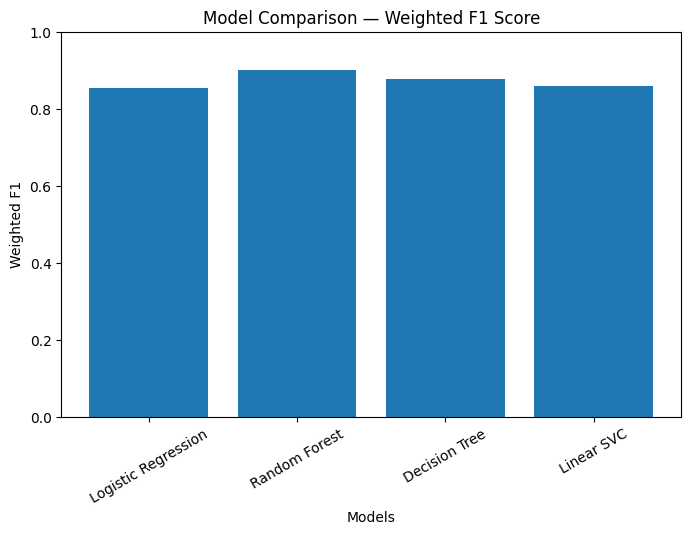

In [116]:
plt.figure(figsize=(8,5))
plt.bar(model_names, weighted_f1_scores)
plt.title("Model Comparison — Weighted F1 Score")
plt.xlabel("Models")
plt.ylabel("Weighted F1")
plt.xticks(rotation=30)
plt.ylim(0,1)
plt.show()

Random Forest has the highest Weighted F1 score, meaning it performs best on the most common (large) classes.

Decision Tree is slightly behind Random Forest, showing strong performance but a bit less consistent.

Linear SVC and Logistic Regression have similar Weighted F1 scores, indicating decent performance but weaker than tree-based models on dominant classes.

# ___________________________________________________________________________________________________________________________